# Word2Vec training

This notebook is based on the [word2vec-pytorch](https://github.com/OlgaChernytska/word2vec-pytorch/tree/18d4f24c4d82dde76de9f6e4d88bbcbcf68befc2) repo.

In [1]:
import kagglehub


path = kagglehub.dataset_download("bestwater/wikitext-2-v1")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'wikitext-2-v1' dataset.
Path to dataset files: /kaggle/input/wikitext-2-v1


In [7]:
!ls /kaggle/input/wikitext-2-v1

wikitext-2


In [ ]:
!mv /root/.cache/kagglehub/datasets/bestwater/wikitext-2-v1/versions/1/wikitext-2 /home/wikitext-2

In [2]:
!ls wikitext-2

ls: cannot access 'wikitext-2': No such file or directory


In [3]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams.update({'font.size': 14})

In [8]:
TRAIN_TOKENS = '/kaggle/input/wikitext-2-v1/wikitext-2/wiki.train.tokens'
VALID_TOKENS = '/kaggle/input/wikitext-2-v1/wikitext-2/wiki.valid.tokens'

SKIPGRAM_N_WORDS = 4
MIN_WORD_FREQUENCY = 5
MAX_SEQUENCE_LENGTH = 256

EMBED_DIM = 256
EMBED_MAX_NORM = 1
BATCH_SIZE = 16
NUM_EPOCHS = 20

In [9]:
import re


def basic_english_tokenizer(text):
    """
    Simple tokenizer that mimics torchtext's basic_english tokenizer.
    Converts text to lowercase and splits on whitespace and punctuation.
    """
    # Convert to lowercase
    text = text.lower()
    # Split on whitespace and punctuation, keeping alphanumeric sequences
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

tokenizer = basic_english_tokenizer

def load_and_preprocess_dataset(path):
    with open(path, 'r') as file:
        lines = file.readlines()

        print(lines[1001])

    data = list(filter(
        lambda sent: len(sent) > SKIPGRAM_N_WORDS * 2,
        map(tokenizer, lines)
    ))

    return data

In [11]:
train_data = load_and_preprocess_dataset(TRAIN_TOKENS)
valid_data = load_and_preprocess_dataset(VALID_TOKENS)

total_train_tokens = sum(len(sent) for sent in train_data)
total_valid_tokens = sum(len(sent) for sent in valid_data)

print(f'Num sentences: train - {len(train_data)}, valid - {len(valid_data)})')
print(f'Total tokens: train - {total_train_tokens}, valid - {total_valid_tokens})')
print(f'Average tokens in sentence: {total_train_tokens / len(train_data):.2f}')

 = = Original design = = 

 For financial and <unk> reasons the last book was divided into two films , shot back to back , which drew criticism from the series ' fanbase . <unk> defended the split , stating that it would have been impossible to properly adapt the final novel into a single film . He added that the last movie was going to be extremely fast @-@ paced with a lot of action , while the first part would be far more <unk> , focusing on character development ; he added that , had they combined them , those things would not have made it to the final cut . Filming lasted for a year , concluding in June 2010 and on the last day of shooting , like most of the cast and crew , <unk> openly <unk> . 

Num sentences: train - 16021, valid - 1710)
Total tokens: train - 1729696, valid - 181555)
Average tokens in sentence: 107.96


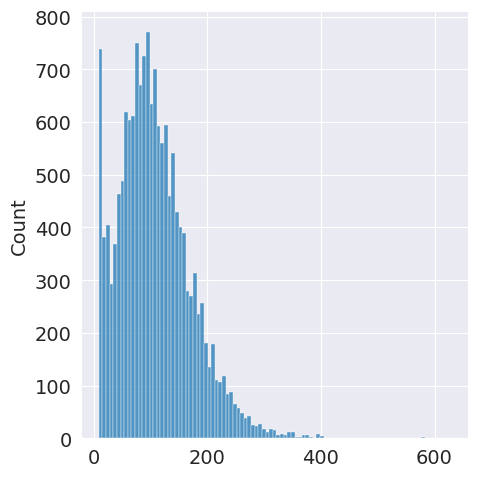

In [12]:
_ = sns.displot([len(sent) for sent in train_data])

In [14]:
from collections import Counter, OrderedDict


class Vocab:
    """
    Custom vocabulary class that mimics torchtext's vocab functionality.
    """
    def __init__(self, iterator, specials=None, min_freq=1):
        if specials is None:
            specials = []

        # Count word frequencies
        counter = Counter()
        for tokens in iterator:
            counter.update(tokens)

        # Build vocabulary: specials first, then words above min_freq
        self.itos = list(specials)
        self.stoi = {token: idx for idx, token in enumerate(self.itos)}

        # Add words that meet min_freq requirement
        for word, freq in counter.items():
            if freq >= min_freq and word not in self.stoi:
                self.itos.append(word)
                self.stoi[word] = len(self.itos) - 1

        self.default_index = self.stoi.get(specials[0] if specials else None, 0)

    def set_default_index(self, index):
        """Set the default index for unknown words."""
        self.default_index = index

    def __call__(self, tokens):
        """Convert tokens to indices."""
        if isinstance(tokens, str):
            tokens = [tokens]
        return [self.stoi.get(token, self.default_index) for token in tokens]

    def __getitem__(self, token):
        """Get index for a token."""
        return self.stoi.get(token, self.default_index)

    def __len__(self):
        """Return vocabulary size."""
        return len(self.itos)

    def get_itos(self):
        """Get index-to-string mapping."""
        return self.itos


vocab = Vocab(train_data, specials=["<unk>"], min_freq=MIN_WORD_FREQUENCY)
vocab.set_default_index(vocab["<unk>"])

VOCAB_SIZE = len(vocab)
print(f'Vocab size: {VOCAB_SIZE}')

Vocab size: 20208


In [17]:
train_data[250]

['in',
 'myth',
 'the',
 'gods',
 'behave',
 'much',
 'like',
 'humans',
 'they',
 'feel',
 'emotion',
 'they',
 'can',
 'eat',
 'drink',
 'fight',
 'unk',
 'unk',
 'and',
 'die',
 'some',
 'have',
 'unique',
 'character',
 'traits',
 'set',
 'is',
 'aggressive',
 'and',
 'impulsive',
 'and',
 'thoth',
 'patron',
 'of',
 'writing',
 'and',
 'knowledge',
 'is',
 'prone',
 'to',
 'long',
 'unk',
 'speeches',
 'yet',
 'overall',
 'the',
 'gods',
 'are',
 'more',
 'like',
 'unk',
 'than',
 'well',
 'drawn',
 'characters',
 'their',
 'behavior',
 'is',
 'inconsistent',
 'and',
 'their',
 'thoughts',
 'and',
 'motivations',
 'are',
 'rarely',
 'stated',
 'most',
 'myths',
 'about',
 'them',
 'lack',
 'highly',
 'developed',
 'characters',
 'and',
 'plots',
 'because',
 'the',
 'symbolic',
 'meaning',
 'of',
 'the',
 'myths',
 'was',
 'more',
 'important',
 'than',
 'elaborate',
 'storytelling']

In [16]:
vocab(train_data[250])

[36,
 4244,
 10,
 4141,
 4431,
 646,
 171,
 4170,
 191,
 4432,
 4433,
 191,
 188,
 4434,
 4435,
 408,
 5,
 5,
 29,
 4436,
 224,
 312,
 288,
 97,
 4220,
 874,
 19,
 4437,
 29,
 0,
 29,
 0,
 4394,
 9,
 3075,
 29,
 1346,
 19,
 4438,
 14,
 1198,
 5,
 4439,
 1191,
 767,
 10,
 4141,
 69,
 95,
 171,
 5,
 229,
 1249,
 3775,
 175,
 266,
 4411,
 19,
 4440,
 29,
 266,
 4441,
 29,
 0,
 69,
 4094,
 562,
 373,
 4162,
 639,
 225,
 3416,
 840,
 26,
 175,
 29,
 4442,
 1188,
 10,
 4343,
 382,
 9,
 10,
 4162,
 117,
 95,
 3163,
 229,
 4443,
 4444]

In [15]:
vocab(['president']), vocab(['ewkeryambus']), vocab(['kittty'])

([1193], [0], [0])

In [18]:
def collate_fn(batch):
    """
    Collate_fn for Skip-Gram model to be used with Dataloader.
    `batch` is expected to be list of text paragrahs.

    Context is represented as N=SKIPGRAM_N_WORDS past words
    and N=SKIPGRAM_N_WORDS future words.

    Long paragraphs will be truncated to contain
    no more that MAX_SEQUENCE_LENGTH tokens.

    Each element in `batch_input` is a middle word.
    Each element in `batch_output` is a context word.
    """
    batch_input, batch_output = [], []
    for text in batch:
        text_tokens_ids = vocab(text)

        if MAX_SEQUENCE_LENGTH:
            text_tokens_ids = text_tokens_ids[:MAX_SEQUENCE_LENGTH]

        for idx in range(len(text_tokens_ids) - SKIPGRAM_N_WORDS * 2):
            token_id_sequence = text_tokens_ids[idx : (idx + SKIPGRAM_N_WORDS * 2 + 1)]
            input_ = token_id_sequence.pop(SKIPGRAM_N_WORDS)
            outputs = token_id_sequence

            batch_input += [input_] * len(outputs)
            batch_output += outputs

    batch_input = torch.LongTensor(batch_input)
    batch_output = torch.LongTensor(batch_output)

    return batch_input, batch_output

In [19]:
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    num_workers=8,
    pin_memory=True,
    collate_fn=collate_fn,
    shuffle=True
)

valid_loader = DataLoader(
    valid_data,
    batch_size=BATCH_SIZE,
    num_workers=8,
    pin_memory=True,
    collate_fn=collate_fn,
    shuffle=False
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [20]:
next(iter(train_loader))

[tensor([  9,   9,   9,  ..., 640, 640, 640]),
 tensor([11475,     5,    10,  ...,  1647,   259, 13912])]

In [21]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Optimizer
from tqdm import tqdm


def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        loss.backward()

        total_loss += loss.item()

        optimizer.step()

    return total_loss / len(data_loader)

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

    return total_loss / len(data_loader)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

In [24]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title, scheduler=None):
    train_loss_history, valid_loss_history = [], []

    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            title
        )

        if scheduler is not None:
            scheduler.step()

In [25]:
from torch import nn


class Word2VecModel(nn.Module):
    def __init__(self, embed_dim, embed_max_norm, vocab_size):
        super().__init__()

        self.embeds = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            max_norm=embed_max_norm
        )

        self.decoder = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        return self.decoder(self.embeds(x))

In [26]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)

loss_fn = nn.CrossEntropyLoss()

cuda:0


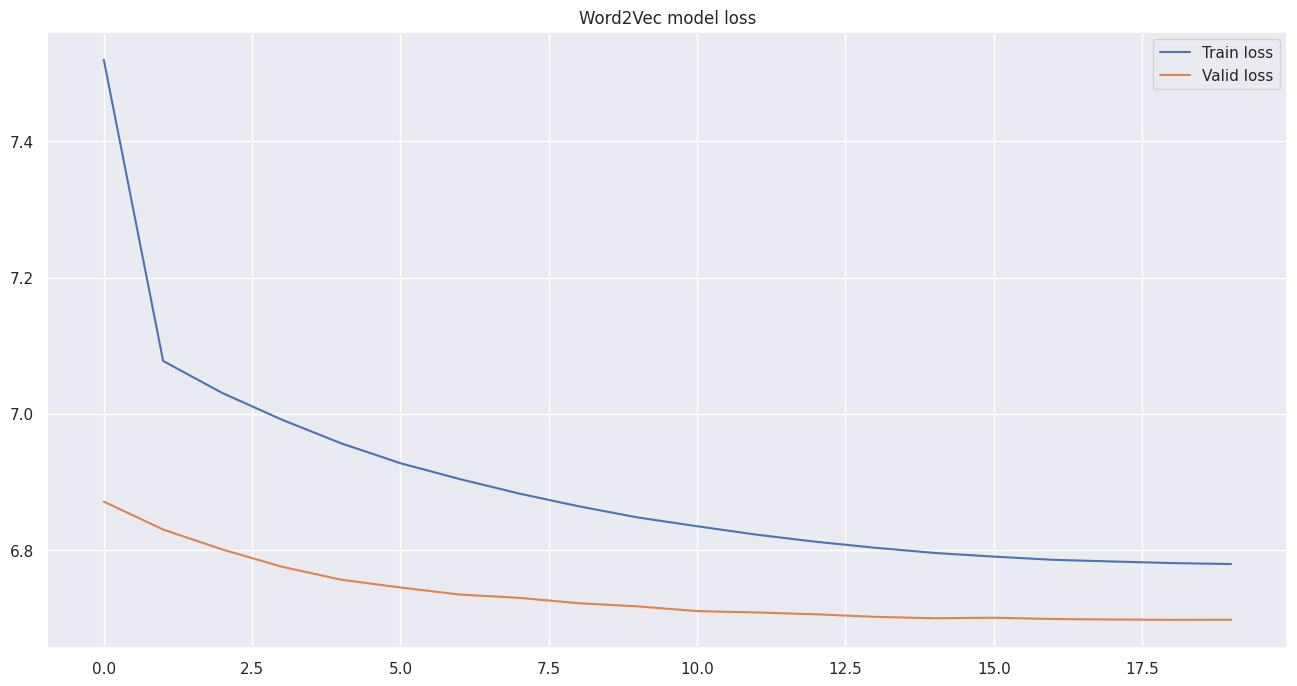

In [ ]:
model = Word2VecModel(
    embed_dim=EMBED_DIM,
    embed_max_norm=EMBED_MAX_NORM,
    vocab_size=VOCAB_SIZE
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, NUM_EPOCHS)

fit(model, train_loader, valid_loader, optimizer, loss_fn, device, NUM_EPOCHS, 'Word2Vec model', scheduler)

In [ ]:
torch.save(model.state_dict(), "word2vec.pt")

In [27]:
model = Word2VecModel(
    embed_dim=EMBED_DIM,
    embed_max_norm=EMBED_MAX_NORM,
    vocab_size=VOCAB_SIZE
).to(device)

In [28]:
model.load_state_dict(torch.load("word2vec.pt"))

<All keys matched successfully>

In [31]:
import re


def get_similarities(embed_vector):
    similarities = embed_matrix @ embed_vector / embed_norms / torch.norm(embed_vector)
    top_indices = similarities.argsort(descending=True)
    return similarities, top_indices


def get_similar(query, num_similar=5):
    print(f'Processing query \"{query}\"')
    split_query = re.split('([^a-zA-Z0-9])', query)
    index = vocab[split_query[0]]
    embed_vector = torch.clone(embed_matrix[index])
    if index > 0:
        print(f'Found word \"{split_query[0]}\" in vocab')
    else:
        print(f'Word \"{split_query[0]}\" not in vocab, using <unk>')

    for i in range(2, len(split_query), 2):
        index = vocab[split_query[i]]
        if index > 0:
            print(f'Found word \"{split_query[i]}\" in vocab, ', end='')
        else:
            print(f'Word \"{split_query[i]}\" not in vocab, using <unk>, ', end='')
        print(f'operation \"{split_query[i - 1]}\"')

        if split_query[i - 1] == '+':
            embed_vector += embed_matrix[index]
        elif split_query[i - 1] == '-':
            embed_vector -= embed_matrix[index]
        else:
            raise ValueError('Unknown operation')

    similarities, top_indices = get_similarities(embed_vector)

    itos = vocab.get_itos()
    print('Top similar:')
    for top_index in top_indices[:num_similar]:
        print(f'    {itos[top_index]}: sim = {similarities[top_index]:.4f}')

In [30]:
embed_matrix = model.embeds.weight.detach().cpu()
embed_norms = (embed_matrix ** 2).sum(1).sqrt()

In [32]:
get_similar('woman')

Processing query "woman"
Found word "woman" in vocab
Top similar:
    woman: sim = 1.0000
    girl: sim = 0.7980
    jealous: sim = 0.7442
    herself: sim = 0.7254
    pregnant: sim = 0.7226


In [33]:
get_similar('man')

Processing query "man"
Found word "man" in vocab
Top similar:
    man: sim = 1.0000
    bearded: sim = 0.8095
    mega: sim = 0.7937
    boss: sim = 0.7507
    woman: sim = 0.6978


In [34]:
get_similar('kick')

Processing query "kick"
Found word "kick" in vocab
Top similar:
    kick: sim = 1.0000
    touchdown: sim = 0.8555
    offense: sim = 0.8427
    yard: sim = 0.8424
    tech: sim = 0.8415


In [35]:
get_similar('help')

Processing query "help"
Found word "help" in vocab
Top similar:
    help: sim = 1.0000
    keep: sim = 0.6854
    distract: sim = 0.6745
    convinces: sim = 0.6744
    try: sim = 0.6679


In [36]:
get_similar('bread')

Processing query "bread"
Found word "bread" in vocab
Top similar:
    bread: sim = 1.0000
    cheese: sim = 0.7465
    dole: sim = 0.6413
    tea: sim = 0.6250
    widows: sim = 0.6024


In [42]:
get_similar('apple')

Processing query "apple"
Found word "apple" in vocab
Top similar:
    apple: sim = 1.0000
    collaborated: sim = 0.6378
    adam: sim = 0.5723
    tito: sim = 0.5689
    jermaine: sim = 0.5613


In [45]:
v = get_similar('unk-man+woman', num_similar=10)

Processing query "unk-man+woman"
Found word "unk" in vocab
Found word "man" in vocab, operation "-"
Found word "woman" in vocab, operation "+"
Top similar:
    unk: sim = 0.7892
    leon: sim = 0.5479
    andrzej: sim = 0.5247
    à: sim = 0.5130
    devi: sim = 0.5085
    stanisław: sim = 0.5041
    kazimierz: sim = 0.5038
    var: sim = 0.4950
    karol: sim = 0.4856
    jan: sim = 0.4836


In [47]:
get_similar('man+man')

Processing query "man+man"
Found word "man" in vocab
Found word "man" in vocab, operation "+"
Top similar:
    man: sim = 1.0000
    bearded: sim = 0.8095
    mega: sim = 0.7937
    boss: sim = 0.7507
    woman: sim = 0.6978


In [48]:
get_similar('king+russia')

Processing query "king+russia"
Found word "king" in vocab
Found word "russia" in vocab, operation "+"
Top similar:
    russia: sim = 0.8340
    king: sim = 0.8340
    narasimha: sim = 0.7555
    conquered: sim = 0.7547
    vira: sim = 0.7491


# FastText for sentiment classification

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivkumarganesh/bumble-dating-app-google-play-store-review")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bumble-dating-app-google-play-store-review' dataset.
Path to dataset files: /kaggle/input/bumble-dating-app-google-play-store-review


In [5]:
!pip install fasttext

import pandas as pd
import fasttext
import fasttext.util

In [6]:
# fasttext.util.download_model('en')
ft = fasttext.load_model('cc.en.300.bin')

In [7]:
ft.get_word_vector('mother').shape

(300,)

In [7]:
!ls /root/.cache/kagglehub/datasets/shivkumarganesh/bumble-dating-app-google-play-store-review/versions/197

bumble_google_play_reviews.csv


In [8]:
import pandas as pd

data = pd.read_csv('/root/.cache/kagglehub/datasets/shivkumarganesh/bumble-dating-app-google-play-store-review/versions/197/bumble_google_play_reviews.csv')
data = data[data.content.notna()]
data

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,e334120e-a603-44fc-a06e-a85b4a4edef0,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,best dating sites ever,5,0,5.444.0,2025-11-29 22:19:50,NaN,NaN,5.444.0
1,e7105834-6629-43a6-bb20-7b76d4912e02,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Can't ever tell if these dating apps are real ...,3,0,5.444.0,2025-11-29 21:47:06,NaN,NaN,5.444.0
2,f4689db4-c0bb-47bb-8fe8-550d63681ea3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Theres no point. after two months of almost da...,1,0,NaN,2025-11-29 21:38:36,NaN,NaN,NaN
3,16affd4b-3c10-4481-a552-6c976e7ca9be,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"west of money, don't use it. Facebook is bette...",1,0,5.444.0,2025-11-29 21:33:44,NaN,NaN,5.444.0
4,025fbb6a-2362-479b-ac7b-bf08ace50f4a,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,This was once the best dating app. Now there's...,2,0,5.444.0,2025-11-29 20:40:23,NaN,NaN,5.444.0
...,...,...,...,...,...,...,...,...,...,...,...
173854,61bc7cdc-3085-4631-ac95-d8e42e2e0742,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Finally here!,5,54,1.0.1,2015-12-01 02:17:24,NaN,NaN,1.0.1
173855,24d07489-88ad-496a-80ce-8f137c130323,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Finally!,5,74,1.0.1,2015-12-01 02:09:05,NaN,NaN,1.0.1
173856,22a42d0d-7a12-400d-a2af-826f35d21581,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Finally, an app where women have to start the ...",4,2,1.0.1,2015-12-01 00:18:53,NaN,NaN,1.0.1
173857,2480a41f-8863-4948-9f83-7d856bd9dc78,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,At last we have Android version!,5,60,1.0.0,2015-11-30 21:27:51,NaN,NaN,1.0.0


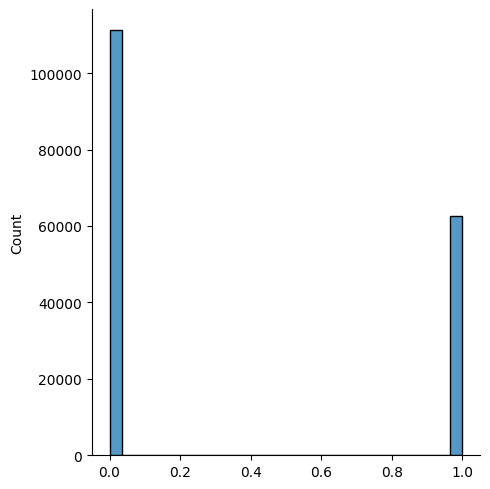

In [9]:
import seaborn as sns

X = data.content.apply(fasttext.tokenize).to_list()
y = (data.score >= 4).to_numpy().astype(int)
_ = sns.displot(y)

In [13]:
X[:10]

[['best', 'dating', 'sites', 'ever'],
 ["Can't",
  'ever',
  'tell',
  'if',
  'these',
  'dating',
  'apps',
  'are',
  'real',
  'or',
  'filled',
  'with',
  'bots.',
  'Let',
  'tou',
  'know',
  'if',
  'I',
  'find',
  'a',
  'date.'],
 ['Theres',
  'no',
  'point.',
  'after',
  'two',
  'months',
  'of',
  'almost',
  'daily',
  'use,',
  'i',
  'get',
  '2-3',
  'people',
  'to',
  'swipe',
  'on',
  'a',
  'busy',
  'day.',
  'usually',
  'just',
  'one',
  'a',
  'day,',
  'if',
  'that.',
  'and',
  'none',
  'of',
  'these',
  'people',
  'are',
  'the',
  'two',
  'who',
  'have',
  'apparently',
  'swiped',
  'right',
  'for',
  'me.',
  'this',
  'app',
  'is',
  'masquerading',
  'as',
  'a',
  'free',
  'dating',
  'app',
  'when',
  'it',
  'will',
  'only',
  'allows',
  'you',
  'to',
  'get',
  'a',
  'match',
  'if',
  'you',
  'pay',
  'and',
  'utilize',
  'premium',
  'features.',
  'Boo',
  'may',
  'give',
  'you',
  'people',
  'from',
  'really',
  'farawa

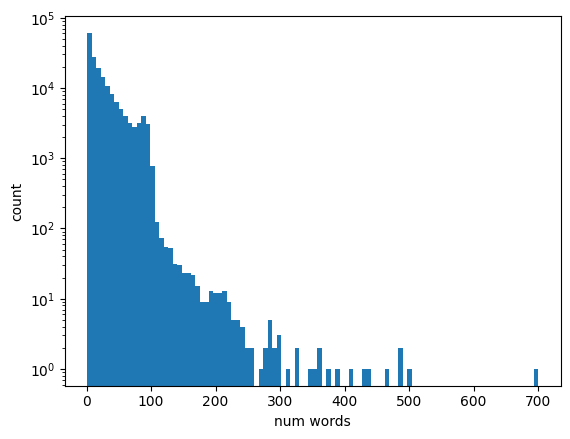

In [15]:
import matplotlib.pyplot as plt

plt.hist([len(sent) for sent in X], bins=100)
plt.yscale('log')
plt.ylabel('count')
plt.xlabel('num words')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=3407)
len(X_train), len(X_valid)

(130381, 43461)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [18]:
X_train_sents = [' '.join(sent) for sent in X_train]
X_valid_sents = [' '.join(sent) for sent in X_valid]

In [19]:
tf_idf = TfidfVectorizer(min_df=5).fit(X_train_sents)
tf_idf_train = tf_idf.transform(X_train_sents)
tf_idf_valid = tf_idf.transform(X_valid_sents)

tf_idf_train.shape, tf_idf_valid.shape

((130381, 9568), (43461, 9568))

In [20]:
lr = LogisticRegression(max_iter=1000).fit(tf_idf_train, y_train)

In [21]:
print(f'Tf-idf + LogRegr train acc: {accuracy_score(lr.predict(tf_idf_train), y_train):.4f}')
print(f'Tf-idf + LogRegr valid acc: {accuracy_score(lr.predict(tf_idf_valid), y_valid):.4f}')

Tf-idf + LogRegr train acc: 0.9031
Tf-idf + LogRegr valid acc: 0.8957


In [11]:
def get_sentence_embedding(sent):
    embeds = []
    for word in sent:
        embeds += [ft.get_word_vector(word)]

    return np.stack(embeds, axis=0).mean(0)

In [12]:
import numpy as np

train_embeds = np.stack([get_sentence_embedding(sent) for sent in X_train], axis=0)
valid_embeds = np.stack([get_sentence_embedding(sent) for sent in X_valid], axis=0)

In [25]:
train_embeds.shape

(130381, 300)

In [26]:
lr = LogisticRegression(max_iter=1000).fit(train_embeds, y_train)

In [27]:
print(f'FastText + LogRegr train acc: {accuracy_score(lr.predict(train_embeds), y_train):.4f}')
print(f'FastText + LogRegr valid acc: {accuracy_score(lr.predict(valid_embeds), y_valid):.4f}')

FastText + LogRegr train acc: 0.8561
FastText + LogRegr valid acc: 0.8574


In [15]:
BATCH_SIZE = 128
MAX_SEQUENCE_LENGTH = 256
MODEL_BLOCKS = 2
MODEL_CHANNELS = 300
NUM_EPOCHS = 5

In [13]:
from torch.utils.data import Dataset, DataLoader

class EmbeddingsDataset(Dataset):
    def __init__(self, sents, targets, max_length):
        super().__init__()

        self.max_length = max_length
        self.sents = sents
        self.targets = targets

    def __len__(self):
        return len(self.sents)

    def __getitem__(self, item):
        sent = self.sents[item]

        length = min(len(sent), self.max_length)

        embeds = []

        for word in sent[:length]:
            embeds += [torch.from_numpy(ft.get_word_vector(word).astype(np.float32))]

        embeds = torch.stack(embeds, dim=1)

        padding = torch.zeros((embeds.shape[0], self.max_length - length))

        embeds = torch.cat([embeds, padding], dim=1)

        return embeds, length, self.targets[item]

In [16]:
train_set = EmbeddingsDataset(X_train, y_train, max_length=MAX_SEQUENCE_LENGTH)
valid_set = EmbeddingsDataset(X_valid, y_valid, max_length=MAX_SEQUENCE_LENGTH)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, num_workers=8,
                          pin_memory=True, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, num_workers=8,
                         pin_memory=True, shuffle=False)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## TextCNN (Text Convolutional Neural Network)

TextCNN is a convolutional neural network architecture designed for text classification tasks. It was introduced by Kim (2014) in the paper "Convolutional Neural Networks for Sentence Classification."

### Key Components:

1. **Convolutional Layers**: TextCNN applies 1D convolutions over the sequence of word embeddings. Unlike traditional CNNs for images that use 2D convolutions, TextCNN uses 1D convolutions because text is a sequential 1D structure.

2. **Multiple Kernel Sizes**: The original TextCNN uses multiple filter sizes (e.g., 3, 4, 5) to capture n-gram features of different lengths simultaneously. This allows the model to detect patterns at different scales (e.g., bigrams, trigrams, 4-grams).

3. **Feature Extraction**: Each convolutional filter slides over the word embeddings and extracts local features. The filters learn to detect important patterns like phrases, word combinations, or semantic structures.

4. **Pooling**: After convolution, max-pooling or average-pooling is typically applied to capture the most important features from each filter. This also handles variable-length sequences.

5. **Classification**: The pooled features are concatenated and passed through a fully connected layer for final classification.

### Advantages:
- **Efficient**: Fast training and inference compared to RNNs/LSTMs
- **Parallelizable**: Convolutions can be computed in parallel, unlike sequential RNNs
- **Multi-scale Features**: Captures features at different n-gram levels simultaneously
- **Simple Architecture**: Easy to implement and understand

### In this implementation:
The TextCNN model uses a residual-style architecture with BasicBlock modules. Each BasicBlock contains two 1D convolutional layers with batch normalization and residual connections, allowing the model to learn deeper representations while maintaining gradient flow. The final classification uses masked average pooling over the sequence length to handle variable-length inputs.


In [17]:
from torch import nn

class BasicBlock(nn.Module):
    def __init__(self, num_channels, kernel_size):
        super().__init__()
        padding = (kernel_size - 1) // 2

        self.conv1 = nn.Conv1d(
            num_channels,
            num_channels,
            kernel_size,
            padding=padding,
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(num_channels)

        self.conv2 = nn.Conv1d(
            num_channels,
            num_channels,
            kernel_size,
            padding=padding,
            bias=False
        )
        self.bn2 = nn.BatchNorm1d(num_channels)
        self.relu = nn.LeakyReLU(0.1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out + x)
        return out

class TextCNN(nn.Module):
    def __init__(self, num_blocks, num_channels, num_classes, kernel_size=5):
        super().__init__()

        self.backbone = nn.Sequential(
            *[BasicBlock(num_channels, kernel_size) for _ in range(num_blocks)]
        )

        self.classifier = nn.Linear(num_channels, num_classes)

    @staticmethod
    def get_lengths_mask(embeds, lengths):
        mask = torch.arange(embeds.shape[-1]).unsqueeze(0).to(embeds.device)
        mask = (mask < lengths.unsqueeze(1)).to(torch.float)
        return mask.unsqueeze(1)

    def forward(self, embeds, lengths):
        # embeds: (B, C, T), lengths: (B, )
        features = self.backbone(embeds)
        # features: (B, C, T)
        mask = self.get_lengths_mask(embeds, lengths)
        # mask: (B, 1, T)
        features = (features * mask).sum(-1) / lengths.unsqueeze(1)
        # features: (B, C)
        logits = self.classifier(features)
        # logits: (B, num_classes)
        return logits

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Optimizer
from tqdm import tqdm

def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0
    total_correct = 0

    for embeds, lengths, labels in tqdm(data_loader):
        embeds = embeds[..., :lengths.max()]

        embeds, lengths, labels = embeds.to(device), lengths.to(device), labels.to(device)

        optimizer.zero_grad()

        output = model(embeds, lengths)

        loss = loss_fn(output, labels)

        loss.backward()

        total_loss += loss.item()
        total_correct += (output.argmax(1) == labels).sum().item()

        optimizer.step()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [19]:
@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0
    total_correct = 0

    for embeds, lengths, labels in tqdm(data_loader):
        embeds = embeds[..., :lengths.max()]

        embeds, lengths, labels = embeds.to(device), lengths.to(device), labels.to(device)

        output = model(embeds, lengths)

        loss = loss_fn(output, labels)

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == labels).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [24]:
import matplotlib.pyplot as plt

def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

In [25]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title, scheduler=None):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        if scheduler is not None:
            scheduler.step()

In [26]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)

model = TextCNN(num_blocks=MODEL_BLOCKS, num_channels=MODEL_CHANNELS, num_classes=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, NUM_EPOCHS)

criterion = nn.CrossEntropyLoss()

cuda:0


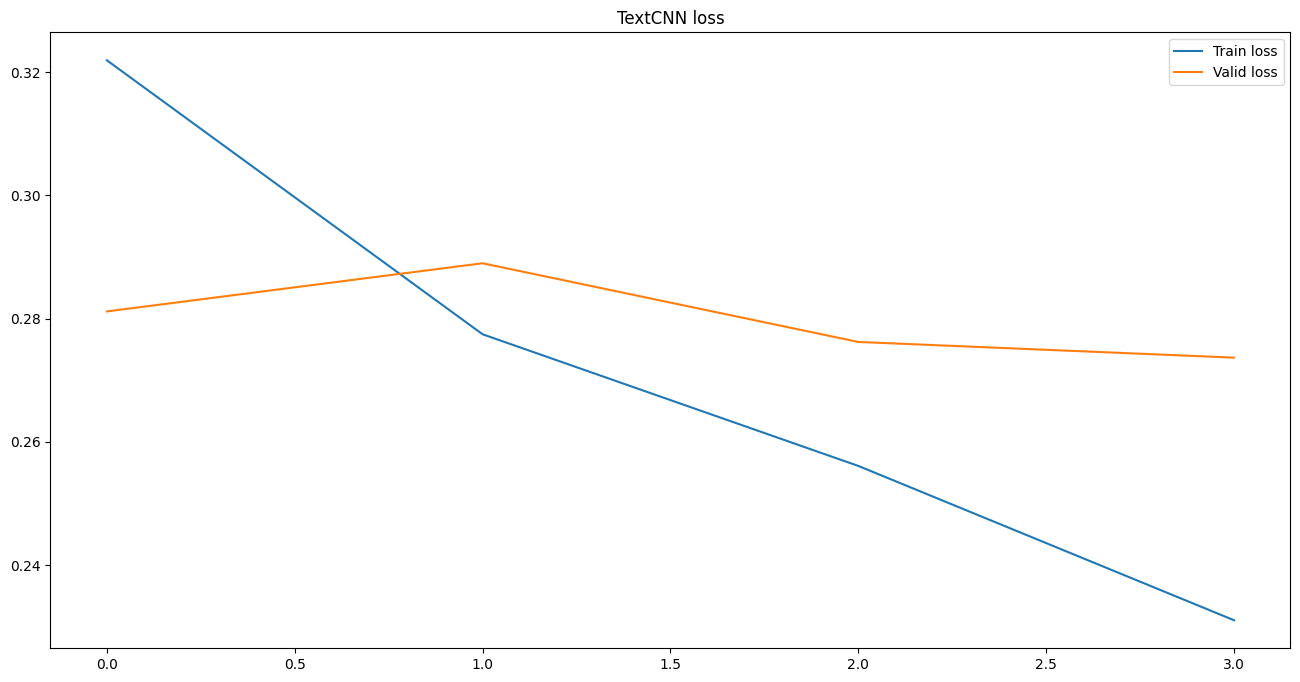

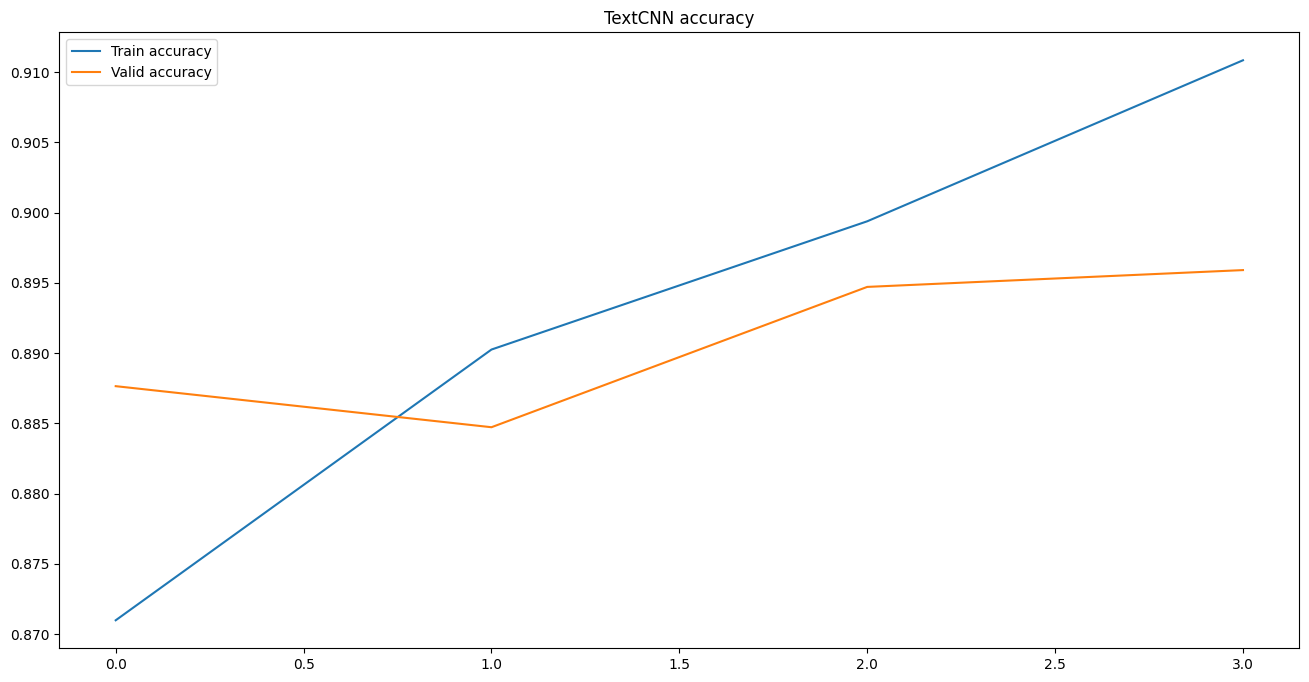

 32%|███▏      | 330/1019 [00:35<01:00, 11.33it/s]

In [ ]:
fit(model, train_loader, valid_loader, optimizer, criterion, device, NUM_EPOCHS, 'TextCNN', scheduler)